# AISO 척력 튜닝 + Runtime 비교
# 목표: Crowding-DE(1.000), SPSO(0.987) 따라잡기
# 핵심: M 범위, 척력 가중치, k 조합

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})

N_AG  = 40
N_IT  = 200
N_RUN = 20
PEAK_R = 0.12
N_TYPES = 12
BETA    = 0.08

np.random.seed(42)
print('설정 완료')

설정 완료


In [2]:
# ── 함수 + 유틸 ───────────────────────────────────────────────
def make_gaussian_mixture(peaks, sigma=0.07):
    peaks = np.array(peaks)
    def f(x):
        x2 = np.array(x)[:2]
        return -float(sum(np.exp(-np.sum((x2-p)**2)/(2*sigma**2)) for p in peaks))
    return f, peaks

def make_himmelblau():
    optima_orig = np.array([[3.0,2.0],[-2.805118,3.131312],
                            [-3.779310,-3.283186],[3.584428,-1.848126]])
    optima = (optima_orig + 5) / 10
    def f(x):
        z = np.array(x)[:2]*10-5
        return float((z[0]**2+z[1]-11)**2+(z[0]+z[1]**2-7)**2)
    return f, optima

PEAKS_4 = np.array([[0.2,0.2],[0.2,0.8],[0.8,0.2],[0.8,0.8]])
PEAKS_6 = np.array([[0.15,0.15],[0.15,0.85],[0.85,0.15],[0.85,0.85],[0.5,0.15],[0.5,0.85]])
PEAKS_9 = np.array([[i*0.35+0.15, j*0.35+0.15] for i in range(3) for j in range(3)])
GM4,OPT4  = make_gaussian_mixture(PEAKS_4, sigma=0.08)
GM6,OPT6  = make_gaussian_mixture(PEAKS_6, sigma=0.07)
GM9,OPT9  = make_gaussian_mixture(PEAKS_9, sigma=0.06)
HB,OPTHB  = make_himmelblau()
MULTIMODAL = [(GM4,OPT4,'4-GM'),(GM6,OPT6,'6-GM'),(GM9,OPT9,'9-GM'),(HB,OPTHB,'Himmelblau')]

def peak_ratio(positions, optima, radius=PEAK_R):
    found = set()
    for pos in positions:
        for k, opt in enumerate(optima):
            if np.linalg.norm(np.array(pos)-opt) < radius:
                found.add(k)
    return len(found) / len(optima)

def diversity(positions):
    pos = np.array(positions); n = len(pos)
    d = [np.linalg.norm(pos[i]-pos[j]) for i in range(n) for j in range(i+1,n)]
    return float(np.mean(d)) if d else 0.

print('함수 준비 완료')

함수 준비 완료


## 척력 파라미터 튜닝

튜닝 대상:
- `m_low`: M의 하한 (척력 강도) — [-0.5, -1, -2, -3]
- `w_repel`: 척력 가중치 (인력=1.0 고정, 척력만 조절) — [1.0, 1.5, 2.0, 3.0]
- `k`: top-k 인력+척력 — [1, 2, 3, 5]
- `alpha`: 이동 크기 — [0.1, 0.2, 0.3]

In [3]:
# ── AISO 튜닝 가능 버전 ───────────────────────────────────────
# w_repel: 척력 항에 추가 가중치 (인력은 1.0 고정)
def run_aiso_tuned(f, optima, seed, k=3, alpha=0.2, m_low=-1.0, w_repel=1.0):
    np.random.seed(seed)
    K=2
    M = np.random.uniform(m_low, 2.0, (N_TYPES, N_TYPES))
    X = np.random.rand(N_AG, K)
    W = np.random.dirichlet(np.ones(N_TYPES), N_AG)
    S = np.array([f(X[i]) for i in range(N_AG)])
    for _ in range(N_IT):
        C = W @ M @ W.T; np.fill_diagonal(C, 0)
        for i in range(N_AG):
            ci = C[i].copy(); ci[i] = 0
            top_a = np.argsort(ci)[-k:]
            top_r = np.argsort(ci)[:k]
            # 인력 (가중치 1.0) + 척력 (가중치 w_repel)
            Fv  = sum(ci[ja]*(X[ja]-X[i]) for ja in top_a)
            Fv += w_repel * sum(ci[jr]*(X[jr]-X[i]) for jr in top_r)
            Fv /= (2*k)
            nX = np.clip(X[i]+alpha*Fv, 0, 1); ns = f(nX)
            if ns < S[i]:
                X[i]=nX; S[i]=ns
                bja = top_a[np.argmax(ci[top_a])]
                W[i]=(1-BETA)*W[i]+BETA*W[bja]; W[i]/=W[i].sum()
    return X, S, peak_ratio(X,optima), diversity(X)


# ── 그리드 서치 ────────────────────────────────────────────────
M_LOWS   = [-0.5, -1.0, -2.0, -3.0]
W_REPELS = [1.0, 1.5, 2.0, 3.0]
KS       = [1, 2, 3, 5]
ALPHAS   = [0.1, 0.2, 0.3]

# 빠른 평가: 4개 함수 × N_RUN=10
N_RUN_FAST = 10
grid_results = {}

print('그리드 서치 시작...')
best_pr = 0; best_cfg = None

# 1단계: m_low × w_repel (k=3, alpha=0.2 고정)
print('\n[1단계] m_low × w_repel (k=3, alpha=0.2)')
stage1 = {}
for m_low in M_LOWS:
    for w_rep in W_REPELS:
        cfg = f'm{m_low}_wr{w_rep}'
        prs = []
        for fn, opts, name in MULTIMODAL:
            pr_list = [run_aiso_tuned(fn, opts, seed=42+r, k=3, alpha=0.2,
                                      m_low=m_low, w_repel=w_rep)[2]
                       for r in range(N_RUN_FAST)]
            prs.append(np.mean(pr_list))
        avg = np.mean(prs)
        stage1[cfg] = {'avg_pr': avg, 'm_low': m_low, 'w_repel': w_rep}
        if avg > best_pr:
            best_pr = avg; best_cfg = cfg
        print(f'  m_low={m_low:5.1f}  w_repel={w_rep:.1f}  →  PR={avg:.4f}')

best1 = max(stage1, key=lambda x: stage1[x]['avg_pr'])
best_m  = stage1[best1]['m_low']
best_wr = stage1[best1]['w_repel']
print(f'\n  최적: m_low={best_m}, w_repel={best_wr}  PR={stage1[best1]["avg_pr"]:.4f}')

그리드 서치 시작...

[1단계] m_low × w_repel (k=3, alpha=0.2)
  m_low= -0.5  w_repel=1.0  →  PR=0.9326
  m_low= -0.5  w_repel=1.5  →  PR=0.9326
  m_low= -0.5  w_repel=2.0  →  PR=0.9549
  m_low= -0.5  w_repel=3.0  →  PR=0.9479
  m_low= -1.0  w_repel=1.0  →  PR=0.9326
  m_low= -1.0  w_repel=1.5  →  PR=0.9458
  m_low= -1.0  w_repel=2.0  →  PR=0.9521
  m_low= -1.0  w_repel=3.0  →  PR=0.9479
  m_low= -2.0  w_repel=1.0  →  PR=0.9479
  m_low= -2.0  w_repel=1.5  →  PR=0.9361
  m_low= -2.0  w_repel=2.0  →  PR=0.9139
  m_low= -2.0  w_repel=3.0  →  PR=0.9167
  m_low= -3.0  w_repel=1.0  →  PR=0.9340
  m_low= -3.0  w_repel=1.5  →  PR=0.9278
  m_low= -3.0  w_repel=2.0  →  PR=0.9243
  m_low= -3.0  w_repel=3.0  →  PR=0.9312

  최적: m_low=-0.5, w_repel=2.0  PR=0.9549


In [4]:
# 2단계: k × alpha (best m_low, w_repel 고정)
print(f'\n[2단계] k × alpha (m_low={best_m}, w_repel={best_wr})')
stage2 = {}
for k in KS:
    for alpha in ALPHAS:
        cfg = f'k{k}_a{alpha}'
        prs = []
        for fn, opts, name in MULTIMODAL:
            pr_list = [run_aiso_tuned(fn, opts, seed=42+r, k=k, alpha=alpha,
                                      m_low=best_m, w_repel=best_wr)[2]
                       for r in range(N_RUN_FAST)]
            prs.append(np.mean(pr_list))
        avg = np.mean(prs)
        stage2[cfg] = {'avg_pr': avg, 'k': k, 'alpha': alpha}
        print(f'  k={k}  alpha={alpha:.1f}  →  PR={avg:.4f}')

best2   = max(stage2, key=lambda x: stage2[x]['avg_pr'])
best_k  = stage2[best2]['k']
best_al = stage2[best2]['alpha']
print(f'\n  최적: k={best_k}, alpha={best_al}  PR={stage2[best2]["avg_pr"]:.4f}')
print(f'\n  ★ 최종 설정: m_low={best_m}, w_repel={best_wr}, k={best_k}, alpha={best_al}')


[2단계] k × alpha (m_low=-0.5, w_repel=2.0)
  k=1  alpha=0.1  →  PR=0.9479
  k=1  alpha=0.2  →  PR=0.9479
  k=1  alpha=0.3  →  PR=0.9417
  k=2  alpha=0.1  →  PR=0.9417
  k=2  alpha=0.2  →  PR=0.9417
  k=2  alpha=0.3  →  PR=0.9354
  k=3  alpha=0.1  →  PR=0.9417
  k=3  alpha=0.2  →  PR=0.9549
  k=3  alpha=0.3  →  PR=0.9417
  k=5  alpha=0.1  →  PR=0.9417
  k=5  alpha=0.2  →  PR=0.9417
  k=5  alpha=0.3  →  PR=0.9417

  최적: k=3, alpha=0.2  PR=0.9549

  ★ 최종 설정: m_low=-0.5, w_repel=2.0, k=3, alpha=0.2


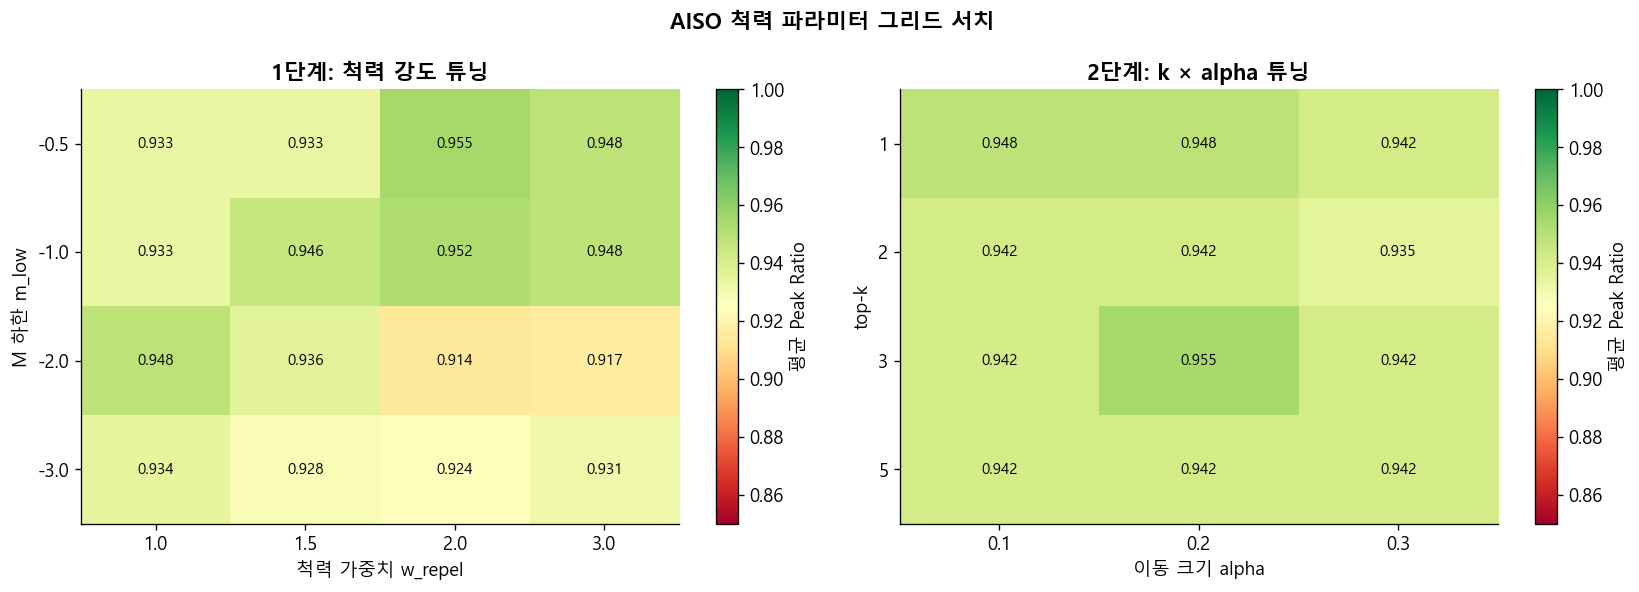

In [5]:
# 그리드 서치 히트맵 (1단계: m_low × w_repel)
m_vals  = M_LOWS
wr_vals = W_REPELS
heat = np.zeros((len(m_vals), len(wr_vals)))
for i, m in enumerate(m_vals):
    for j, wr in enumerate(wr_vals):
        heat[i,j] = stage1[f'm{m}_wr{wr}']['avg_pr']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
im = ax.imshow(heat, cmap='RdYlGn', vmin=0.85, vmax=1.0, aspect='auto')
plt.colorbar(im, ax=ax, label='평균 Peak Ratio')
ax.set_xticks(range(len(wr_vals))); ax.set_xticklabels([f'{v}' for v in wr_vals])
ax.set_yticks(range(len(m_vals)));  ax.set_yticklabels([f'{v}' for v in m_vals])
ax.set_xlabel('척력 가중치 w_repel'); ax.set_ylabel('M 하한 m_low')
ax.set_title('1단계: 척력 강도 튜닝', fontweight='bold')
for i in range(len(m_vals)):
    for j in range(len(wr_vals)):
        ax.text(j, i, f'{heat[i,j]:.3f}', ha='center', va='center', fontsize=9)

# 2단계: k × alpha
k_vals = KS; a_vals = ALPHAS
heat2 = np.zeros((len(k_vals), len(a_vals)))
for i, k in enumerate(k_vals):
    for j, a in enumerate(a_vals):
        heat2[i,j] = stage2[f'k{k}_a{a}']['avg_pr']

ax = axes[1]
im2 = ax.imshow(heat2, cmap='RdYlGn', vmin=0.85, vmax=1.0, aspect='auto')
plt.colorbar(im2, ax=ax, label='평균 Peak Ratio')
ax.set_xticks(range(len(a_vals))); ax.set_xticklabels([f'{v}' for v in a_vals])
ax.set_yticks(range(len(k_vals))); ax.set_yticklabels([f'{v}' for v in k_vals])
ax.set_xlabel('이동 크기 alpha'); ax.set_ylabel('top-k')
ax.set_title('2단계: k × alpha 튜닝', fontweight='bold')
for i in range(len(k_vals)):
    for j in range(len(a_vals)):
        ax.text(j, i, f'{heat2[i,j]:.3f}', ha='center', va='center', fontsize=9)

plt.suptitle('AISO 척력 파라미터 그리드 서치', fontweight='bold')
plt.tight_layout()
plt.savefig('aiso_tuning_grid.png', bbox_inches='tight')
plt.show()

## 최종 비교 + Runtime 측정

AISO(기본) vs AISO(튜닝) vs SOTA 전체  
runtime = N_RUN 평균 실행시간 (초/run)

In [6]:
# ── 모든 비교 알고리즘 정의 ───────────────────────────────────
def run_aiso_base(f, optima, seed):
    return run_aiso_tuned(f, optima, seed, k=3, alpha=0.2, m_low=-1.0, w_repel=1.0)

def run_aiso_best(f, optima, seed):
    return run_aiso_tuned(f, optima, seed, k=best_k, alpha=best_al,
                          m_low=best_m, w_repel=best_wr)

def run_pso(f, optima, seed):
    np.random.seed(seed); K=2; w,c1,c2=0.729,1.494,1.494
    X=np.random.rand(N_AG,K); V=np.zeros((N_AG,K))
    S=np.array([f(X[i]) for i in range(N_AG)])
    pX=X.copy(); pS=S.copy(); gi=np.argmin(pS); gX=pX[gi].copy(); gS=pS[gi]
    for _ in range(N_IT):
        r1,r2=np.random.rand(N_AG,K),np.random.rand(N_AG,K)
        V=w*V+c1*r1*(pX-X)+c2*r2*(gX-X); X=np.clip(X+V,0,1)
        S=np.array([f(X[i]) for i in range(N_AG)])
        bt=S<pS; pX[bt]=X[bt]; pS[bt]=S[bt]
        if pS.min()<gS: gi=np.argmin(pS); gX=pX[gi].copy(); gS=pS[gi]
    return X, S, peak_ratio(X,optima), diversity(X)

def run_spso(f, optima, seed, r_species=0.2):
    np.random.seed(seed); K=2; w,c1,c2=0.729,1.494,1.494
    X=np.random.rand(N_AG,K); V=np.zeros((N_AG,K))
    S=np.array([f(X[i]) for i in range(N_AG)])
    pX=X.copy(); pS=S.copy()
    for _ in range(N_IT):
        order=np.argsort(pS); assigned=np.zeros(N_AG,dtype=bool)
        seed_map=np.zeros(N_AG,dtype=int)
        for i in order:
            if not assigned[i]:
                for j in range(N_AG):
                    if np.linalg.norm(pX[i]-pX[j])<r_species:
                        assigned[j]=True; seed_map[j]=i
        for i in range(N_AG):
            r1,r2=np.random.rand(K),np.random.rand(K)
            V[i]=w*V[i]+c1*r1*(pX[i]-X[i])+c2*r2*(pX[seed_map[i]]-X[i])
            X[i]=np.clip(X[i]+V[i],0,1)
        S=np.array([f(X[i]) for i in range(N_AG)])
        bt=S<pS; pX[bt]=X[bt]; pS[bt]=S[bt]
    return X, S, peak_ratio(X,optima), diversity(X)

def run_crowding_de(f, optima, seed, F=0.5, CR=0.9):
    np.random.seed(seed); K=2
    X=np.random.rand(N_AG,K); S=np.array([f(X[i]) for i in range(N_AG)])
    for _ in range(N_IT):
        for i in range(N_AG):
            pool=[j for j in range(N_AG) if j!=i]
            r1,r2,r3=np.random.choice(pool,3,replace=False)
            mutant=np.clip(X[r1]+F*(X[r2]-X[r3]),0,1)
            mask=np.random.rand(K)<CR; trial=np.where(mask,mutant,X[i])
            dists=np.array([np.linalg.norm(X[j]-trial) for j in range(N_AG)])
            dists[i]=np.inf; crowd=np.argmin(dists); ns=f(trial)
            if ns<S[crowd]: X[crowd]=trial; S[crowd]=ns
    return X, S, peak_ratio(X,optima), diversity(X)

ALL_ALGOS = {
    'AISO(기본)'  : run_aiso_base,
    'AISO(튜닝)'  : run_aiso_best,
    'PSO'         : run_pso,
    'SPSO'        : run_spso,
    'Crowding-DE' : run_crowding_de,
}
print('알고리즘:', list(ALL_ALGOS.keys()))

알고리즘: ['AISO(기본)', 'AISO(튜닝)', 'PSO', 'SPSO', 'Crowding-DE']


In [7]:
# ── PR + Runtime 동시 측정 ─────────────────────────────────────
final_results = {}   # {aname: {fname: {'pr':[], 'div':[], 'rt':[]}}}
fn_names = [n for _,_,n in MULTIMODAL]

for aname, afunc in ALL_ALGOS.items():
    print(f'\n── {aname} ──')
    final_results[aname] = {}
    for fn, opts, fname in MULTIMODAL:
        pr_list, div_list, rt_list = [], [], []
        for r in range(N_RUN):
            t0 = time.perf_counter()
            _, _, pr, dv = afunc(fn, opts, seed=42+r)
            rt = time.perf_counter() - t0
            pr_list.append(pr); div_list.append(dv); rt_list.append(rt)
        final_results[aname][fname] = {'pr': pr_list, 'div': div_list, 'rt': rt_list}
        print(f'  {fname:<12} PR={np.mean(pr_list):.3f}  '
              f'div={np.mean(div_list):.3f}  rt={np.mean(rt_list):.3f}s')
print('\n✓ 완료!')


── AISO(기본) ──
  4-GM         PR=0.988  div=0.429  rt=0.939s
  6-GM         PR=0.917  div=0.462  rt=0.873s
  9-GM         PR=0.928  div=0.445  rt=1.088s
  Himmelblau   PR=0.925  div=0.401  rt=0.508s

── AISO(튜닝) ──
  4-GM         PR=0.988  div=0.429  rt=0.995s
  6-GM         PR=0.925  div=0.463  rt=0.811s
  9-GM         PR=0.928  div=0.443  rt=1.078s
  Himmelblau   PR=0.938  div=0.399  rt=0.538s

── PSO ──
  4-GM         PR=0.250  div=0.004  rt=0.304s
  6-GM         PR=0.200  div=0.018  rt=0.427s
  9-GM         PR=0.139  div=0.019  rt=0.641s
  Himmelblau   PR=0.325  div=0.030  rt=0.081s

── SPSO ──
  4-GM         PR=1.000  div=0.511  rt=0.788s
  6-GM         PR=0.992  div=0.544  rt=0.987s
  9-GM         PR=0.956  div=0.510  rt=1.441s
  Himmelblau   PR=1.000  div=0.500  rt=0.571s

── Crowding-DE ──
  4-GM         PR=1.000  div=0.515  rt=2.389s
  6-GM         PR=1.000  div=0.558  rt=2.263s
  9-GM         PR=1.000  div=0.503  rt=2.076s
  Himmelblau   PR=1.000  div=0.504  rt=1.761s

✓ 완료!

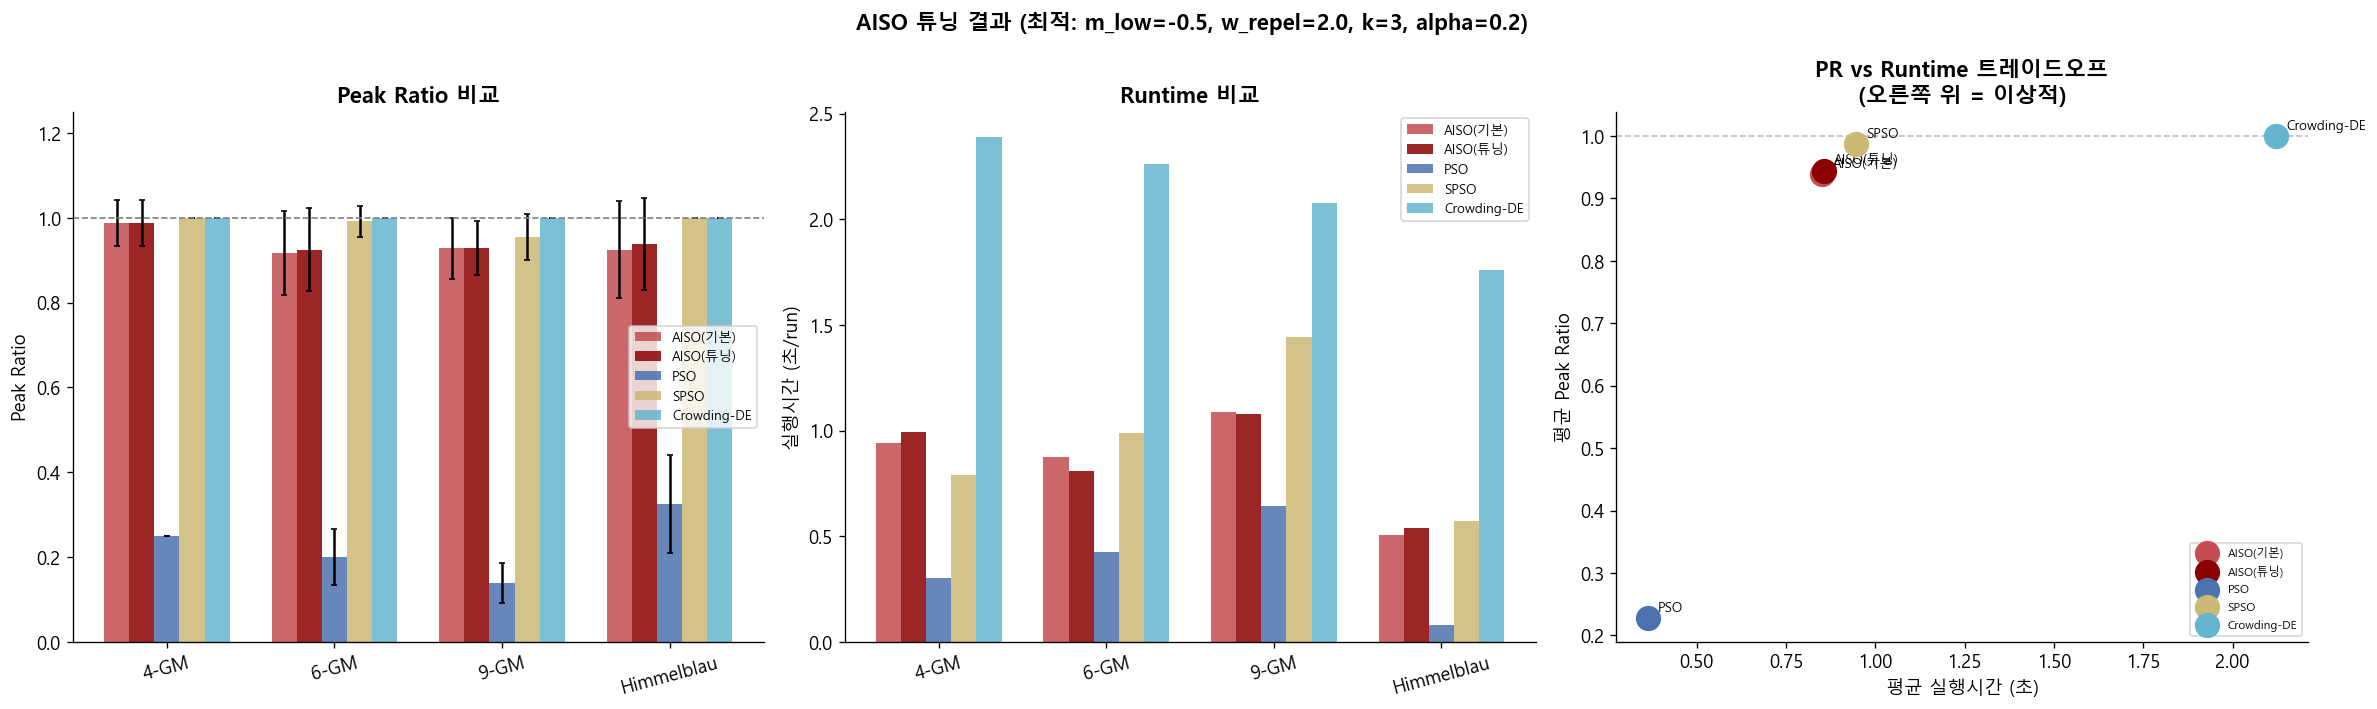


=== 최종 순위 (평균 PR) ===
  1위  Crowding-DE   : PR=1.0000  RT=2.122s
  2위  SPSO          : PR=0.9868  RT=0.947s
  3위  AISO(튜닝)      : PR=0.9444  RT=0.855s ★
  4위  AISO(기본)      : PR=0.9392  RT=0.852s ★
  5위  PSO           : PR=0.2285  RT=0.363s


In [8]:
# ── 최종 결과 시각화 ──────────────────────────────────────────
COLORS = {
    'AISO(기본)' :'#C44E52', 'AISO(튜닝)':'#8B0000',
    'PSO'        :'#4C72B0', 'SPSO'      :'#CCB974',
    'Crowding-DE':'#64B5CD'
}
algo_order = list(ALL_ALGOS.keys())

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# [1] Peak Ratio 바차트
ax = axes[0]
x = np.arange(len(fn_names)); width = 0.15
for k, aname in enumerate(algo_order):
    pr_means = [np.mean(final_results[aname][fn]['pr']) for fn in fn_names]
    pr_stds  = [np.std(final_results[aname][fn]['pr'])  for fn in fn_names]
    ax.bar(x+k*width, pr_means, width, label=aname,
           color=COLORS[aname], yerr=pr_stds, capsize=2, alpha=0.85)
ax.axhline(1.0, color='gray', ls='--', lw=1)
ax.set_xticks(x+2*width); ax.set_xticklabels(fn_names, rotation=15)
ax.set_ylabel('Peak Ratio'); ax.set_ylim(0, 1.25)
ax.set_title('Peak Ratio 비교', fontweight='bold'); ax.legend(fontsize=8)

# [2] Runtime 바차트
ax = axes[1]
for k, aname in enumerate(algo_order):
    rt_means = [np.mean(final_results[aname][fn]['rt']) for fn in fn_names]
    ax.bar(x+k*width, rt_means, width, label=aname,
           color=COLORS[aname], alpha=0.85)
ax.set_xticks(x+2*width); ax.set_xticklabels(fn_names, rotation=15)
ax.set_ylabel('실행시간 (초/run)'); ax.set_title('Runtime 비교', fontweight='bold')
ax.legend(fontsize=8)

# [3] PR vs Runtime 트레이드오프 (평균)
ax = axes[2]
for aname in algo_order:
    avg_pr = np.mean([np.mean(final_results[aname][fn]['pr']) for fn in fn_names])
    avg_rt = np.mean([np.mean(final_results[aname][fn]['rt']) for fn in fn_names])
    ax.scatter(avg_rt, avg_pr, s=200, color=COLORS[aname], zorder=5, label=aname)
    ax.annotate(aname, (avg_rt, avg_pr), textcoords='offset points',
                xytext=(6,4), fontsize=8)
ax.axhline(1.0, color='gray', ls='--', lw=1, alpha=0.5)
ax.set_xlabel('평균 실행시간 (초)'); ax.set_ylabel('평균 Peak Ratio')
ax.set_title('PR vs Runtime 트레이드오프\n(오른쪽 위 = 이상적)', fontweight='bold')
ax.legend(fontsize=7)

plt.suptitle(f'AISO 튜닝 결과 (최적: m_low={best_m}, w_repel={best_wr}, k={best_k}, alpha={best_al})',
             fontweight='bold')
plt.tight_layout()
plt.savefig('aiso_tuning_final.png', bbox_inches='tight')
plt.show()

# 최종 순위
print('\n=== 최종 순위 (평균 PR) ===')
ranking = sorted(algo_order,
                 key=lambda a: np.mean([np.mean(final_results[a][fn]['pr']) for fn in fn_names]),
                 reverse=True)
for rank, aname in enumerate(ranking, 1):
    avg_pr = np.mean([np.mean(final_results[aname][fn]['pr']) for fn in fn_names])
    avg_rt = np.mean([np.mean(final_results[aname][fn]['rt']) for fn in fn_names])
    tag = ' ★' if 'AISO' in aname else ''
    print(f'  {rank}위  {aname:<14}: PR={avg_pr:.4f}  RT={avg_rt:.3f}s{tag}')